# 🧠 Complete EEG Processing Pipeline

This notebook provides a complete end-to-end pipeline for processing EEG data:
1. Configuration of data paths (with user-specific bypasses)
2. Building EEG metadata dataframe
3. Extracting comprehensive features (temporal, spectral, functional)
4. Visualizing feature variations across epochs

## Path Configuration
- Electrode locations file: `src/io/ebneuro.elocs`
- H5 data files: 
  - For user 'daniele': OneDrive path contains all subjects (00_01.h5, 00_02.h5, 01_01.h5, etc.)
  - For other users: Default project path `data/processed/`

## Setup and Imports

In [4]:
import re, unicodedata, difflib
import h5py
import pandas as pd
import numpy as np
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

# Add project root to path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

Project root: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech


## Configuration: Path Setup with User-Specific Bypass

In [5]:
# Path configuration function with user-specific bypass
def get_data_paths(user_name: str = None) -> Dict[str, Path]:
    """
    Get data paths with user-specific overrides.
    
    The OneDrive path contains ALL subjects' H5 files:
    - Files are named as {subject_id}_{session_id}.h5
    - Example: 00_01.h5, 00_02.h5, ..., 01_01.h5, 01_02.h5, etc.
    - 5 acquisitions per subject (e.g., 00_01 to 00_05 for subject 00)
    
    For user 'daniele', uses OneDrive path (contains all subjects' data).
    For other users, uses default project paths.
    
    Args:
        user_name: Name of the user (e.g., 'daniele') - NOT the subject ID
    
    Returns:
        Dictionary with 'h5_dir' and 'eloc_path'
    """
    paths = {}
    
    # Electrode locations file - always in src/io
    paths['eloc_path'] = project_root / "src" / "io" / "ebneuro.elocs"
    
    # H5 data files path - user-specific bypass
    if user_name and user_name.lower() == 'daniele':
        # Bypass for user daniele: use OneDrive path (contains ALL subjects' data)
        # All H5 files (00_01.h5, 00_02.h5, 01_01.h5, etc.) are in this directory
        paths['h5_dir'] = Path('/Users/danieleuras/Library/CloudStorage/OneDrive-PolitecnicodiMilano/File di Francesco Iacomi - h5/data')
        print(f"✓ Using daniele's OneDrive path (all subjects): {paths['h5_dir']}")
    else:
        # Default path for other users
        paths['h5_dir'] = project_root / "data" / "processed"
        print(f"✓ Using default path: {paths['h5_dir']}")
    
    # Verify paths exist
    if not paths['eloc_path'].exists():
        print(f"⚠ Warning: Electrode file not found at {paths['eloc_path']}")
    if not paths['h5_dir'].exists():
        print(f"⚠ Warning: H5 directory not found at {paths['h5_dir']}")
    
    return paths

# Configure paths - CHANGE THIS TO YOUR USER NAME
USER_NAME = 'daniele'  # Set to 'daniele' to use OneDrive path (all subjects), or None for default
paths = get_data_paths(USER_NAME)

print(f"\n📁 Configuration:")
print(f"   Electrode file: {paths['eloc_path']}")
print(f"   H5 data dir: {paths['h5_dir']}")
print(f"   Expected files: 00_01.h5, 00_02.h5, ..., 01_01.h5, etc.")

✓ Using daniele's OneDrive path (all subjects): /Users/danieleuras/Library/CloudStorage/OneDrive-PolitecnicodiMilano/File di Francesco Iacomi - h5/data
⚠ Warning: Electrode file not found at /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/src/io/ebneuro.elocs

📁 Configuration:
   Electrode file: /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/src/io/ebneuro.elocs
   H5 data dir: /Users/danieleuras/Library/CloudStorage/OneDrive-PolitecnicodiMilano/File di Francesco Iacomi - h5/data
   Expected files: 00_01.h5, 00_02.h5, ..., 01_01.h5, etc.


## Label Canonicalization Functions

In [6]:
# List of true labels in Italian
true_labels = [
    "arrivare","andare","aspettare","avere","capire","chiamare","chiedere","conoscere","dare","dire","dovere",
    "essere","fare","mettere","potere","prendere","sapere","sentire","trovare","venire","aprire","chiudere",
    "mangiare","bere","accendere","spegnere","volere","bene","si","no","più","poco","molto","sempre","adesso",
    "poi","male","sopra","sotto","destra","sinistra","avanti","indietro","oggi","domani","ieri","forse","prima",
    "perchè","anche","come","però","quindi","quando","dove","se","oppure","io","lui","lei","noi","voi","loro",
    "tu","questo","quello","buono","bello","cattivo","brutto","grande","piccolo","nuovo","vecchio","cosa","parte",
    "anno","casa","problema","aiuto","tempo","lavoro","persona","acqua","cibo","bisogno","donna","uomo","gruppo",
    "guerra","idea","macchina","mano","oggetto","telefono","computer","domanda","uno","mille","paura","ansia",
    "gioia","felicità","tristezza","serenità","amore","morte","bagno","dolore","riposo"
]

def _strip_diacritics(s: str) -> str:
    return ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')

def _robust_decode(x) -> str:
    if isinstance(x, (bytes, bytearray)):
        s = None
        for enc in ('utf-8', 'latin-1', 'cp1252'):
            try:
                s = x.decode(enc)
                break
            except Exception:
                continue
        # fallback if none of the decodings succeeded
        if s is None:
            s = x.decode('utf-8', 'ignore')
    else:
        s = str(x)

    s = s.replace('\x00', '').strip()

    if ('Ã' in s) or ('Â' in s):
        try:
            s = s.encode('latin-1', 'ignore').decode('utf-8', 'ignore')
        except Exception:
            pass

    s = unicodedata.normalize('NFC', s)
    return s

def canonicalize_label(raw) -> str:
    s = _robust_decode(raw).lower()

    s = re.sub(r'\s+', ' ', s).strip()
    s = re.sub(r'_img$', '', s)

    # Normalize various quote characters to simple ASCII quotes
    s = (s.replace("‘", "'")
           .replace("’", "'")
           .replace("‚", "'")
           .replace("“", '"')
           .replace("”", '"')
           .replace("„", '"'))

    s = s.replace("''", "'").replace("´", "'").replace("`", "'").strip()

    fixes = {
        "perche": "perchè", "perche'": "perchè", "perch'e": "perchè", "perchà''": "perchè",
        "pero": "però", "piu": "più", "serenita": "serenità", "felicita": "felicità"
    }
    if s in fixes:
        return fixes[s]

    if s in true_labels:
        return s

    s_ascii = _strip_diacritics(s)
    candidates_ascii = [_strip_diacritics(t) for t in true_labels]

    match1 = difflib.get_close_matches(s_ascii, candidates_ascii, n=1, cutoff=0.7)
    if match1:
        idx = candidates_ascii.index(match1[0])
        return true_labels[idx]

    match2 = difflib.get_close_matches(s, true_labels, n=1, cutoff=0.6)
    if match2:
        return match2[0]

    return s

print("✓ Label canonicalization functions loaded")

✓ Label canonicalization functions loaded


## Build EEG Metadata DataFrame

In [7]:
def build_eeg_dataframe(h5_dir: Path, label2idx: Dict[str, int] = None) -> pd.DataFrame:
    """
    Build EEG metadata dataframe from H5 files.
    
    Args:
        h5_dir: Directory containing H5 files
        label2idx: Dictionary mapping label names to indices (optional)
    
    Returns:
        DataFrame with metadata for each epoch
    """
    rows = []
    
    # Find all H5 files
    h5_files = sorted(h5_dir.glob("*.h5"))
    
    if not h5_files:
        print(f"⚠ No H5 files found in {h5_dir}")
        return pd.DataFrame()
    
    print(f"Found {len(h5_files)} H5 files")
    
    for file in h5_files:
        try:
            # Extract subject and session from filename
            parts = file.stem.split("_")
            subject_id = parts[0] if len(parts) > 0 else "unknown"
            session_id = parts[1] if len(parts) > 1 else "S001"
            
            with h5py.File(file, "r") as f:
                data = f["data"]
                labels = f["labels"][:] # type: ignore
                n_epochs, n_channels, n_samples = data.shape # type: ignore

                for i, lbl_raw in enumerate(labels): # type: ignore
                    label_name = canonicalize_label(lbl_raw)
                    label_idx = label2idx.get(label_name, -1) if label2idx else -1
                    
                    rows.append({
                        "subject_id": subject_id,
                        "session_id": session_id,
                        "epoch_idx": i,
                        "label_name": label_name,
                        "label_idx": label_idx,
                        "n_channels": n_channels,
                        "n_samples": n_samples,
                        "fs": 256,
                        "path_h5": str(file)
                    })
            
            print(f"  ✓ Processed {file.name}: {n_epochs} epochs")
        
        except Exception as e:
            print(f"  ✗ Error processing {file.name}: {e}")
            continue

    df = pd.DataFrame(rows)
    return df

# Build dataframe
print("\n📊 Building EEG metadata dataframe...")
meta_df_eeg = build_eeg_dataframe(paths['h5_dir'])

if not meta_df_eeg.empty:
    # Save to interim directory
    interim_dir = project_root / "data" / "interim"
    interim_dir.mkdir(parents=True, exist_ok=True)
    output_csv = interim_dir / "eeg_metadata.csv"
    meta_df_eeg.to_csv(output_csv, index=False)
    print(f"\n✓ Saved metadata to {output_csv}")
    print(f"\n📈 Dataset Summary:")
    print(f"   Total epochs: {len(meta_df_eeg)}")
    print(f"   Subjects: {meta_df_eeg['subject_id'].nunique()}")
    print(f"   Sessions: {meta_df_eeg['session_id'].nunique()}")
    print(f"   Labels: {meta_df_eeg['label_name'].nunique()}")
    print(f"   Channels: {meta_df_eeg['n_channels'].iloc[0]}")
    
    # Display first few rows
    display(meta_df_eeg.head(10))
else:
    print("⚠ No data found. Please check your H5 directory path.")


📊 Building EEG metadata dataframe...
Found 359 H5 files
  ✓ Processed 00_01.h5: 110 epochs
  ✓ Processed 00_02.h5: 110 epochs
  ✓ Processed 00_03.h5: 110 epochs
  ✓ Processed 00_04.h5: 110 epochs
  ✓ Processed 00_05.h5: 110 epochs
  ✓ Processed 01_01.h5: 110 epochs
  ✓ Processed 01_02.h5: 110 epochs
  ✓ Processed 01_03.h5: 110 epochs
  ✓ Processed 01_04.h5: 110 epochs
  ✓ Processed 01_05.h5: 110 epochs
  ✓ Processed 02_01.h5: 110 epochs
  ✓ Processed 02_02.h5: 110 epochs
  ✓ Processed 02_03.h5: 110 epochs
  ✓ Processed 02_04.h5: 110 epochs
  ✓ Processed 02_05.h5: 110 epochs
  ✓ Processed 03_01.h5: 110 epochs
  ✓ Processed 03_02.h5: 110 epochs
  ✓ Processed 03_03.h5: 110 epochs
  ✓ Processed 03_04.h5: 110 epochs
  ✓ Processed 03_05.h5: 110 epochs
  ✓ Processed 04_01.h5: 110 epochs
  ✓ Processed 04_02.h5: 110 epochs
  ✓ Processed 04_03.h5: 110 epochs
  ✓ Processed 04_04.h5: 110 epochs
  ✓ Processed 04_05.h5: 110 epochs
  ✓ Processed 05_01.h5: 110 epochs
  ✓ Processed 05_02.h5: 110 epoch

,subject_id,session_id,epoch_idx,label_name,label_idx,n_channels,n_samples,fs,path_h5
0,00,01,0,mille,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
1,00,01,1,bello,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
2,00,01,2,dovere,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
3,00,01,3,problema,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
4,00,01,4,io,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
5,00,01,5,poco,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
6,00,01,6,piccolo,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
7,00,01,7,guerra,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
8,00,01,8,morte,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...
9,00,01,9,dolore,-1,61,384,256,/Users/danieleuras/Library/CloudStorage/OneDri...


## Extract Comprehensive Features

This section extracts temporal, spectral, and functional features from the EEG data.

In [5]:
# Import feature extraction functions
try:
    from scripts.features.bandpowers import iterate_all_files_and_compute
    
    print("🔄 Extracting band power features...")
    
    # Extract band powers
    meta_csv = interim_dir / "eeg_metadata.csv"
    if meta_csv.exists():
        df_bandpowers = iterate_all_files_and_compute(
            meta_csv, 
            fs=256, 
            eloc_path=paths['eloc_path']
        )
        
        if not df_bandpowers.empty:
            # Save band powers
            bandpowers_csv = interim_dir / "bandpowers.csv"
            df_bandpowers.to_csv(bandpowers_csv, index=False)
            print(f"\n✓ Extracted band powers: {len(df_bandpowers)} feature vectors")
            print(f"✓ Saved to {bandpowers_csv}")
            
            # Display sample
            display(df_bandpowers.head())
        else:
            print("⚠ No band power features extracted")
    else:
        print(f"⚠ Metadata CSV not found at {meta_csv}")
        
except ImportError as e:
    print(f"⚠ Could not import feature extraction functions: {e}")
    print("   Make sure scripts/features/bandpowers.py exists")
except Exception as e:
    print(f"✗ Error during feature extraction: {e}")

🔄 Extracting band power features...
Not setting metadata
110 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
00 | 01: 6710 rows
Not setting metadata
110 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
00 | 02: 6710 rows
Not setting metadata
110 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
00 | 03: 6710 rows
Not setting metadata
110 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
00 | 04: 6710 rows
Not setting metadata
110 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
00 | 05: 6710 rows
Not setting metadata
110 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 3 columns
01 | 01: 6710 rows
Not setting metadata
1

,subject_id,session_id,epoch_idx,channel,label_name,total_power,delta,theta,alpha,beta,gamma,delta_rel,theta_rel,alpha_rel,beta_rel,gamma_rel,alpha_beta_ratio,theta_alpha_ratio
0,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,01,0,EEG1,mille_img,6.446333,1.346928,2.998469,0.492284,0.751827,0.820818,0.208945,0.465143,0.076367,0.116629,0.127331,0.654784,6.090933
1,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,01,0,EEG2,mille_img,11.993583,4.172407,2.835663,1.057745,2.258754,1.581771,0.347887,0.236432,0.088193,0.188330,0.131885,0.468287,2.680858
2,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,01,0,EEG3,mille_img,21.975962,8.804756,7.468946,1.274366,2.231304,2.141330,0.400654,0.339869,0.057989,0.101534,0.097440,0.571130,5.860911
3,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,01,0,EEG4,mille_img,12.643944,4.930085,2.506228,0.775546,2.698366,1.588710,0.389917,0.198216,0.061337,0.213412,0.125650,0.287413,3.231567
4,[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0...,01,0,EEG5,mille_img,12.223893,2.832214,2.501551,0.456615,3.235375,3.132915,0.231695,0.204644,0.037354,0.264676,0.256294,0.141132,5.478463


In [ ]:
# Comprehensive extraction with resume/append support
# Set to True to run the comprehensive extractor from this notebook
RUN_COMPREHENSIVE = True  # <-- flip to True to execute
# If RESUME=True and output exists, we'll append subjects not yet processed
RESUME = False
# Output path
out_csv = interim_dir / "comprehensive_features.csv"
eloc_path = paths['eloc_path']

if RUN_COMPREHENSIVE:
    print("Starting comprehensive extraction (notebook-controlled)...")
    from scripts.features.comprehensive_features import load_epochs_from_h5, extract_all_features_for_epochs

    # Load metadata (built earlier in the notebook)
    meta = pd.read_csv(interim_dir / "eeg_metadata.csv")
    meta['subject_id'] = meta['subject_id'].astype(str).str.strip()

    subjects = sorted(meta['subject_id'].unique())

    processed_subjects = set()
    if out_csv.exists() and RESUME:
        try:
            prev = pd.read_csv(out_csv)
            processed_subjects = set(prev['subject_id'].astype(str).unique())
            print(f"Resuming: found {len(processed_subjects)} processed subjects in {out_csv}")
        except Exception as e:
            print(f"⚠ Could not read existing output for resume: {e}")
            processed_subjects = set()

    # If not resuming and file exists, overwrite
    if out_csv.exists() and not RESUME:
        print(f"Overwriting existing {out_csv}")
        out_csv.unlink()

    # Iterate per-subject so we can resume later
    for subj in subjects:
        if subj in processed_subjects:
            print(f"Skipping subject {subj} (already processed)")
            continue

        print(f"Processing subject: {subj}")
        subj_meta = meta[meta['subject_id'].astype(str) == str(subj)]
        h5_files = sorted(subj_meta['path_h5'].unique())
        subj_dfs = []

        for p in h5_files:
            pth = Path(p)
            if not pth.is_absolute():
                pth = project_root / 'data' / 'processed' / Path(p).name

            if not pth.exists():
                print(f"  ⚠ Missing file: {pth}")
                continue

            session_id = pth.stem.split('_')[1] if '_' in pth.stem else 'unknown'
            print(f"  ➜ Extracting from {pth.name} (session {session_id})")

            try:
                epochs = load_epochs_from_h5(pth, fs=256, eloc_path=eloc_path)
                df_feats = extract_all_features_for_epochs(epochs, session_id, extract_functional=True)
                subj_dfs.append(df_feats)
                print(f"    ✓ Extracted {len(df_feats)} rows from {pth.name}")
            except Exception as e:
                print(f"    ✗ Error extracting from {pth.name}: {e}")
                continue

        if subj_dfs:
            df_subj = pd.concat(subj_dfs, ignore_index=True)
            # Append or write depending on resume state
            if out_csv.exists() and RESUME:
                df_subj.to_csv(out_csv, mode='a', header=False, index=False)
            else:
                df_subj.to_csv(out_csv, index=False)

            print(f"  ✓ Saved {len(df_subj)} rows for subject {subj} to {out_csv}")
        else:
            print(f"  ⚠ No features extracted for subject {subj}")

    print("Comprehensive extraction (notebook) complete.")
else:
    print("RUN_COMPREHENSIVE is False — set it to True to execute comprehensive extraction from this cell.")


## Feature Visualization: Random Feature Variation Across Epochs

This section visualizes how a randomly selected feature varies across epochs.


📊 Plotting 3 random features: [np.str_('beta_rel'), np.str_('theta_alpha_ratio'), np.str_('total_power')]

✓ Saved visualization to /Users/danieleuras/Documents/GitHub/miralis-hypergraph-imagined-speech/figures/random_feature_variation.png


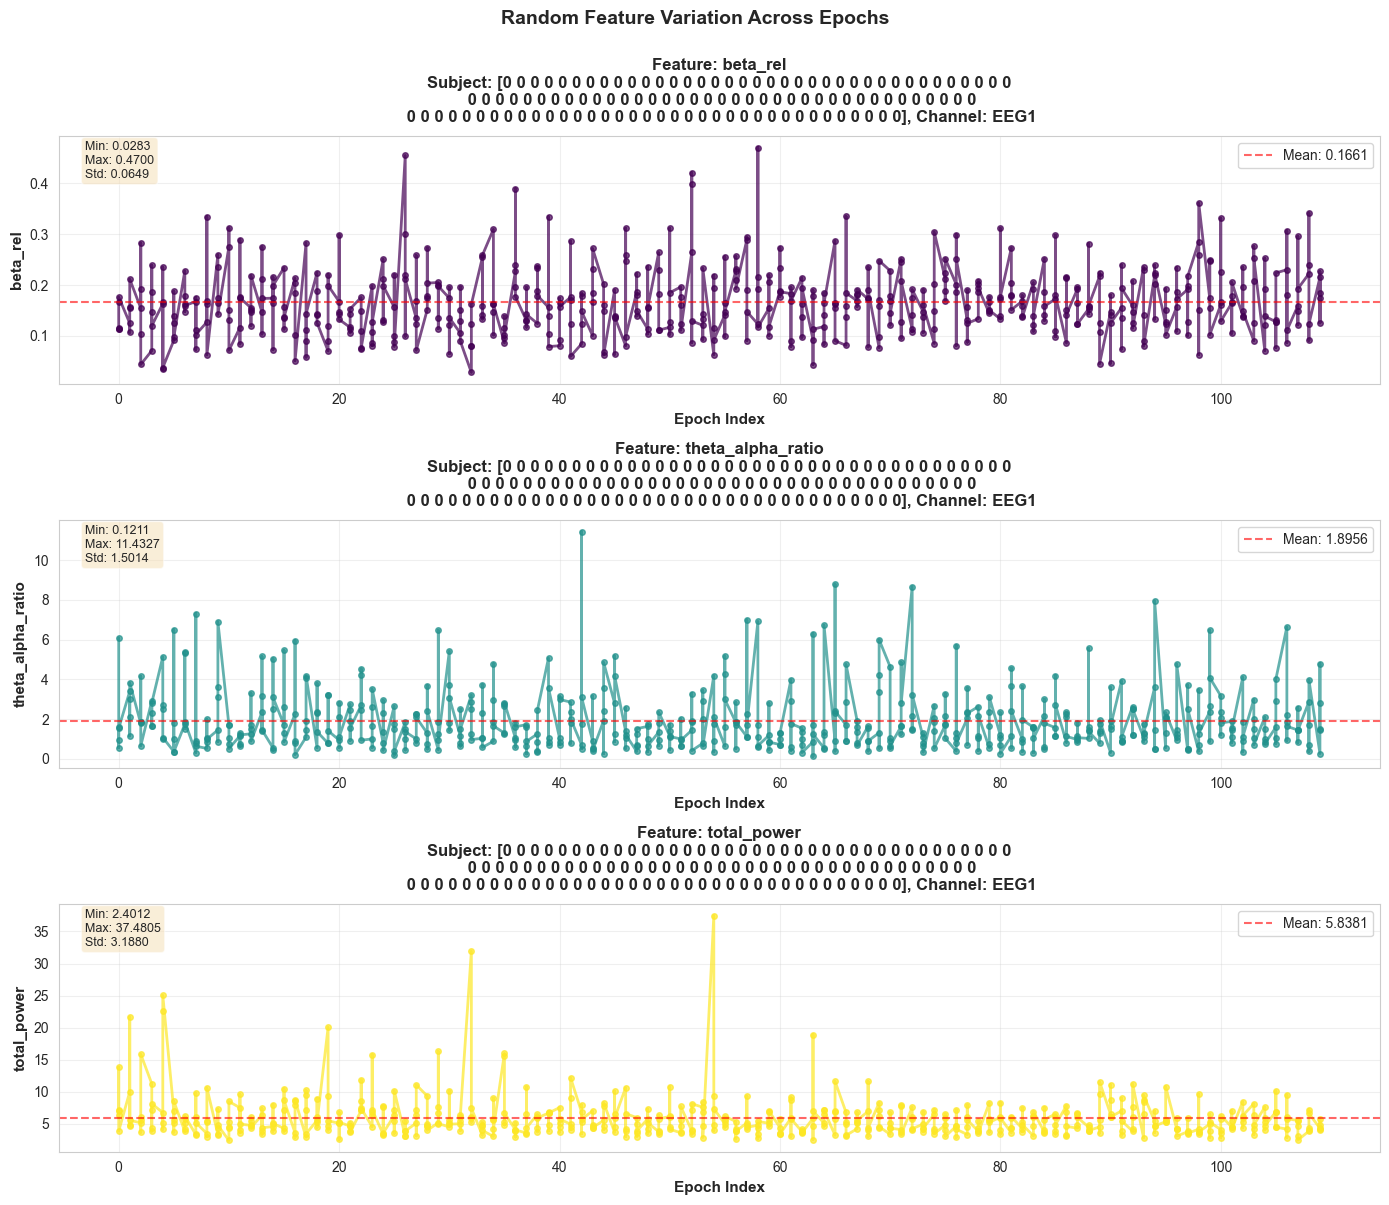

In [6]:
def plot_random_feature_variation(df: pd.DataFrame, n_features: int = 3):
    """
    Plot variation of random features across epochs.
    
    Args:
        df: DataFrame with features
        n_features: Number of random features to plot
    """
    if df.empty:
        print("⚠ No data to visualize")
        return
    
    # Get numeric feature columns (exclude metadata)
    exclude_cols = ['subject_id', 'session_id', 'epoch_idx', 'channel', 'label_name']
    feature_cols = [col for col in df.columns if col not in exclude_cols and df[col].dtype in ['float64', 'int64']]
    
    if not feature_cols:
        print("⚠ No numeric features found")
        return
    
    # Select random features
    n_features = min(n_features, len(feature_cols))
    random_features = np.random.choice(feature_cols, size=n_features, replace=False)
    
    print(f"\n📊 Plotting {n_features} random features: {list(random_features)}")
    
    # Get a single subject and channel for cleaner visualization
    subject = df['subject_id'].iloc[0]
    channel = df['channel'].iloc[0] if 'channel' in df.columns else None
    
    # Filter data
    if channel:
        subset = df[(df['subject_id'] == subject) & (df['channel'] == channel)].copy()
        title_suffix = f"Subject: {subject}, Channel: {channel}"
    else:
        subset = df[df['subject_id'] == subject].copy()
        title_suffix = f"Subject: {subject}"
    
    if subset.empty:
        print("⚠ No data for visualization after filtering")
        return
    
    # Sort by epoch
    subset = subset.sort_values('epoch_idx')
    
    # Create subplots
    fig, axes = plt.subplots(n_features, 1, figsize=(14, 4*n_features))
    if n_features == 1:
        axes = [axes]
    
    colors = plt.cm.viridis(np.linspace(0, 1, n_features))
    
    for idx, (feature, ax, color) in enumerate(zip(random_features, axes, colors)):
        # Plot feature variation
        ax.plot(subset['epoch_idx'], subset[feature], 
                marker='o', linestyle='-', linewidth=2, 
                markersize=4, color=color, alpha=0.7)
        
        # Add mean line
        mean_val = subset[feature].mean()
        ax.axhline(y=mean_val, color='red', linestyle='--', 
                   linewidth=1.5, alpha=0.6, label=f'Mean: {mean_val:.4f}')
        
        # Styling
        ax.set_xlabel('Epoch Index', fontsize=11, fontweight='bold')
        ax.set_ylabel(feature, fontsize=11, fontweight='bold')
        ax.set_title(f'Feature: {feature}\n{title_suffix}', 
                     fontsize=12, fontweight='bold', pad=10)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right', fontsize=10)
        
        # Add statistics
        stats_text = f'Min: {subset[feature].min():.4f}\nMax: {subset[feature].max():.4f}\nStd: {subset[feature].std():.4f}'
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle('Random Feature Variation Across Epochs', 
                 fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    # Save figure
    figures_dir = project_root / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    output_path = figures_dir / "random_feature_variation.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved visualization to {output_path}")
    
    plt.show()

# Create visualization
if 'df_bandpowers' in locals() and not df_bandpowers.empty:
    plot_random_feature_variation(df_bandpowers, n_features=3)
elif not meta_df_eeg.empty:
    print("⚠ Using metadata for visualization (no features extracted yet)")
else:
    print("⚠ No data available for visualization")

## Channel Mapping

Build a mapping between H5 channel names and electrode location names.

In [7]:
def build_channel_mapping(h5_path: Path, eloc_path: Path) -> pd.DataFrame:
    """
    Build channel mapping between H5 file and electrode locations.
    
    Args:
        h5_path: Path to an H5 file
        eloc_path: Path to electrode locations file
    
    Returns:
        DataFrame with channel mapping
    """
    try:
        # Get channel count from H5
        with h5py.File(h5_path, "r") as f:
            n_channels = f["data"].shape[1] # type: ignore
        h5_channels = [f"EEG{i+1}" for i in range(n_channels)]

        # Load electrode names from eloc file
        df_eloc = pd.read_csv(eloc_path, sep=r"\s+", header=None, engine="python", comment='#')
        eloc_channels = df_eloc.iloc[:, -1].astype(str).tolist()

        # Create mapping
        n_min = min(len(h5_channels), len(eloc_channels))
        mapping = pd.DataFrame({
            "channel_index": range(1, n_min + 1),
            "h5_name": h5_channels[:n_min],
            "eloc_name": eloc_channels[:n_min]
        })
        return mapping
    except Exception as e:
        print(f"⚠ Error building channel mapping: {e}")
        return pd.DataFrame()

# Build channel mapping if we have data
if not meta_df_eeg.empty and paths['eloc_path'].exists():
    first_h5 = Path(meta_df_eeg['path_h5'].iloc[0])
    if first_h5.exists():
        print("\n🗺️ Building channel mapping...")
        mapping_df = build_channel_mapping(first_h5, paths['eloc_path'])
        
        if not mapping_df.empty:
            # Save mapping
            mapping_csv = interim_dir / "channel_mapping.csv"
            mapping_df.to_csv(mapping_csv, index=False)
            print(f"✓ Saved channel mapping to {mapping_csv}")
            print(f"✓ Mapped {len(mapping_df)} channels")
            
            # Display mapping
            display(mapping_df.head(10))
    else:
        print(f"⚠ H5 file not found: {first_h5}")
else:
    print("⚠ Cannot build channel mapping: missing data or electrode file")

⚠ Cannot build channel mapping: missing data or electrode file


## Summary and Next Steps

### What This Notebook Does:
1. ✅ Configures paths with user-specific bypasses (e.g., user 'daniele' uses OneDrive path for all subjects)
2. ✅ Builds EEG metadata dataframe from H5 files (00_01.h5, 00_02.h5, 01_01.h5, etc.)
3. ✅ Extracts band power features (delta, theta, alpha, beta, gamma)
4. ✅ Visualizes random feature variations across epochs
5. ✅ Creates channel mapping between H5 and electrode locations

### Data Structure:
- **H5 files naming**: `{subject_id}_{session_id}.h5` (e.g., 00_01, 00_02, ..., 01_01, 01_02, ...)
- **5 acquisitions per subject**: Subject 00 has 00_01 to 00_05, subject 01 has 01_01 to 01_05, etc.
- **All subjects in one directory**: OneDrive path contains all subjects' data

### Output Files:
- `data/interim/eeg_metadata.csv` - Metadata for all epochs
- `data/interim/bandpowers.csv` - Extracted band power features
- `data/interim/channel_mapping.csv` - Channel name mapping
- `figures/random_feature_variation.png` - Feature variation plot

### Next Steps:
1. Extract additional features (temporal, functional)
2. Perform advanced visualizations
3. Build graph representations
4. Train machine learning models

## Label Statistics and Analysis


📊 Label Distribution Analysis:

Top 10 most frequent labels:
label_name
computer    360
ansia       360
domanda     360
sentire     360
sopra       359
mano        359
gioia       359
morte       359
sempre      359
loro        359
Name: count, dtype: int64

📈 Epochs per subject:
subject_id
00        550
01        550
02        550
03        550
04        550
         ... 
70        550
71        550
72        550
73        110
ignore    257
Name: epoch_idx, Length: 75, dtype: int64

🏷️ Unique labels per subject:
subject_id
00        110
01        110
02        110
03        110
04        110
         ... 
70        110
71        110
72        110
73        110
ignore    110
Name: label_name, Length: 75, dtype: int64


NameError: name 'figures_dir' is not defined

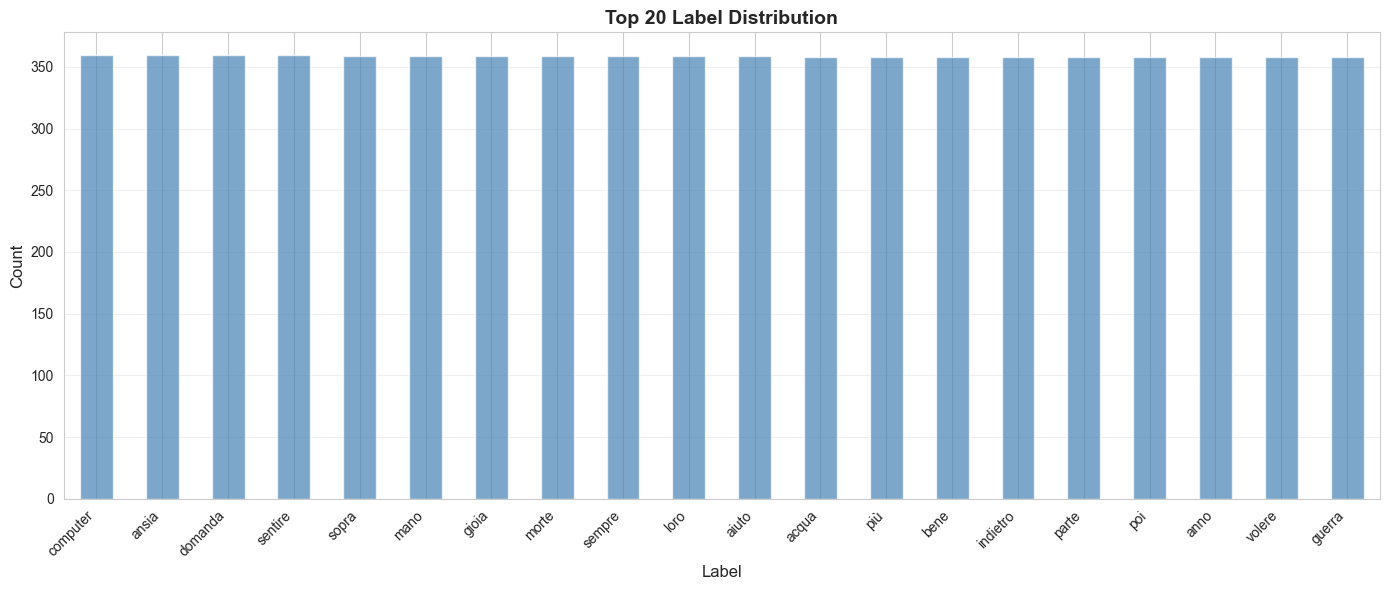

In [ ]:
if not meta_df_eeg.empty:
    print("\n📊 Label Distribution Analysis:\n")
    
    # Count occurrences
    label_counts = meta_df_eeg['label_name'].value_counts()
    print(f"Top 10 most frequent labels:")
    print(label_counts.head(10))
    
    # Epochs per subject
    print(f"\n📈 Epochs per subject:")
    print(meta_df_eeg.groupby('subject_id')['epoch_idx'].count())
    
    # Classes per subject
    print(f"\n🏷️ Unique labels per subject:")
    print(meta_df_eeg.groupby('subject_id')['label_name'].nunique())
    
    # Visualize label distribution
    plt.figure(figsize=(14, 6))
    label_counts.head(20).plot(kind='bar', color='steelblue', alpha=0.7)
    plt.title('Top 20 Label Distribution', fontsize=14, fontweight='bold')
    plt.xlabel('Label', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    
    # Save figure
    figures_dir = project_root / "figures"
    label_dist_path = figures_dir / "label_distribution.png"
    plt.savefig(label_dist_path, dpi=150, bbox_inches='tight')
    print(f"\n✓ Saved label distribution plot to {label_dist_path}")
    
    plt.show()